In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from cycler import cycler 

In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
PALETA = ['#133458', '#838921', '#D99B21', '#FAF7BB']

# Aplica la paleta como ciclo de color por defecto para TODAS las gráficas
plt.rcParams['axes.prop_cycle'] = cycler(color=PALETA)

# Opcional: también fija el estilo general para que se vea consistente
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

In [4]:
diccionario1= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/diccionario_de_datos/diccionario_de_datos_m2s6p1_cnsipef2025.csv', 
                         encoding='utf-8-sig', 
                         low_memory=False
)
diccionario1

,COLUMNA,DESCRIPCION,ORIGEN,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,rnsnni1,Realización de algún traslado de personas privadas de la libertad en los centros penitenciarios federales,SECC VI. 1,Numérico,2,0 al 98
1,traslatt,Total,SECC VI. 1,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
2,trasla1,Voluntarios,SECC VI. 1,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
3,trasla2,Involuntarios,SECC VI. 1,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"


In [5]:
diccionario2= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/diccionario_de_datos/diccionario_de_datos_m2s6p2_cnsipef2025.csv', 
                         encoding='utf-8-sig', 
                         low_memory=False
)
diccionario2

,COLUMNA,DESCRIPCION,ORIGEN,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,motitras_b,Motivo del traslado,SECC VI. 2,Numérico,2,1 al 99
1,traslatt,Total,SECC VI. 2,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
2,trasla1,Voluntarios,SECC VI. 2,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
3,trasla2,Involuntarios,SECC VI. 2,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"


In [6]:
diccionario3= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/diccionario_de_datos/diccionario_de_datos_m2s6p3_cnsipef2025.csv', 
                         encoding='utf-8-sig', 
                         low_memory=False
)
diccionario3

,COLUMNA,DESCRIPCION,ORIGEN,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,traslado_b,Tipo de traslados,SECC VI. 3,Numérico,1,1 al 9
1,rnsnni1,Registro de la ocurrencia de algún incidente durante la realización de traslados,SECC VI. 3,Numérico,2,0 al 98
2,trainctt,Total,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
3,trainc1,Fugas a consecuencia del traslado,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
4,trainc2,Muertes en el transcurso del traslado,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
5,trainc3,Lesiones en el transcurso del traslado,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
6,trainc4,Choques en el transcurso del traslado,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
7,trainc5,Ataques al transporte del traslado,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"
8,trainc6,Otro,SECC VI. 3,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"


In [7]:
diccionario4= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/diccionario_de_datos/diccionario_de_datos_m2s6p4_cnsipef2025.csv', 
                         encoding='utf-8-sig', 
                         low_memory=False
)
diccionario4

,COLUMNA,DESCRIPCION,ORIGEN,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,capaises_c,País receptor,SECC VI. 4,Numérico,2,1 al 99
1,totalca1,Traslados internacionales realizados,SECC VI. 4,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"


In [8]:
diccionario5= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/diccionario_de_datos/diccionario_de_datos_m2s6p5_cnsipef2025.csv', 
                         encoding='utf-8-sig', 
                         low_memory=False
)
diccionario5

,COLUMNA,DESCRIPCION,ORIGEN,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,capaises_c,País solicitante,SECC VI. 5,Numérico,2,1 al 99
1,totalca1,Extradiciones realizadas,SECC VI. 5,Carácter,20,"0-999999999999999, NA, NSS, ND, NP, NULL"


In [9]:
df_exploratorio_in= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/conjunto_de_datos/0_indice_cnsipef2025.csv',
    encoding='utf-8-sig',
    low_memory=False
)
df_exploratorio_in

,ARCHIVO,CONTENIDO
0,m2s6p1,"Traslados de personas privadas de la libertad en los centros penitenciarios federales, según tipo, durante el año 2024."
1,m2s6p2,"Traslados de personas privadas de la libertad en los centros penitenciarios federales, según motivo y tipo, durante el año 2024."
2,m2s6p3,"Traslados de personas privadas de la libertad en los centros penitenciarios federales que presentaron la ocurrencia de algún incidente, según tipo de traslado y tipo de incidente, durante el año 2024."
3,m2s6p4,"Traslados internacionales de personas privadas de la libertad en los centros penitenciarios federales, según país receptor, durante el año 2024."
4,m2s6p5,"Extradiciones de personas privadas de la libertad en los centros penitenciarios federales, según país solicitante, durante el año 2024."


In [10]:
df_exploratorio1= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/conjunto_de_datos/m2s6p1_cnsipef2025.csv',
                             )
df_exploratorio1

,rnsnni1,traslatt,trasla1,trasla2
0,1,1567,1298,269


In [11]:
df_exploratorio2= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/conjunto_de_datos/m2s6p2_cnsipef2025.csv',
                             )
df_exploratorio2

,motitras_b,traslatt,trasla1,trasla2
0,1,1368,1298,70
1,2,183,0,183
2,3,0,0,0
3,4,67,67,0
4,5,66,50,16
5,6,0,0,0
6,7,0,0,0
7,8,0,0,0


In [12]:
df_exploratorio3= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/conjunto_de_datos/m2s6p3_cnsipef2025.csv',
                             )
df_exploratorio3

,traslado_b,rnsnni1,trainctt,trainc1,trainc2,trainc3,trainc4,trainc5,trainc6
0,1,1,27,0,0,1,5,0,21
1,2,1,1,0,1,0,0,0,0


In [13]:
df_exploratorio4= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/conjunto_de_datos/m2s6p4_cnsipef2025.csv',
                             )
df_exploratorio4

,capaises_c,totalca1
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0
5,6,0.0
6,7,0.0
7,8,0.0
8,9,0.0
9,10,0.0


In [14]:
df_exploratorio5= pd.read_csv('Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/conjunto_de_datos/m2s6p5_cnsipef2025.csv',
                             )
df_exploratorio5

,capaises_c,totalca1
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0
5,6,0.0
6,7,0.0
7,8,0.0
8,9,0.0
9,10,0.0


In [15]:
total = df_exploratorio1['traslatt'].iloc[0]
total

np.int64(1567)

In [16]:
voluntarios = df_exploratorio1['trasla1'].iloc[0]
voluntarios

np.int64(1298)

In [17]:
involuntarios = df_exploratorio1['trasla2'].iloc[0]
involuntarios

np.int64(269)

In [18]:
catalogo_motivo = pd.read_csv(
    'Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/catalogos/motitras_b_cnsipef2025.csv',
    encoding='utf-8-sig'
)
catalogo_motivo

,motitras_b,descrip
0,1,Acercamiento al domicilio de la persona privada de la libertad
1,2,Seguridad
2,3,Sobrepoblación
3,4,Salud
4,5,Desahogo de una diligencia ante un tribunal
5,6,Fallecimiento o enfermedad grave de algún familiar
6,7,Desarrollo de actividades recreativas previstas en el plan de actividades
7,8,Otro motivo
8,9,No identificado
9,99,No especificado


In [19]:
df_motivo = df_exploratorio2.merge(catalogo_motivo, on='motitras_b', how='left')
df_motivo = df_motivo.rename(columns={'descrip': 'motivo'})
df_motivo['pct_del_total'] = df_motivo['traslatt'] / total * 100
df_motivo = df_motivo.rename(columns={
    'descrip': 'Motivo',
    'traslatt': 'Total',
    'trasla1': 'Voluntarios',
    'trasla2': 'Involuntarios'
})
df_motivo

,motitras_b,Total,Voluntarios,Involuntarios,motivo,pct_del_total
0,1,1368,1298,70,Acercamiento al domicilio de la persona privada de la libertad,87.300574
1,2,183,0,183,Seguridad,11.678366
2,3,0,0,0,Sobrepoblación,0.000000
3,4,67,67,0,Salud,4.275686
4,5,66,50,16,Desahogo de una diligencia ante un tribunal,4.211870
5,6,0,0,0,Fallecimiento o enfermedad grave de algún familiar,0.000000
6,7,0,0,0,Desarrollo de actividades recreativas previstas en el plan de actividades,0.000000
7,8,0,0,0,Otro motivo,0.000000


In [20]:
df_plot = df_motivo[df_motivo['Total'] > 0].sort_values('Total', ascending=True)

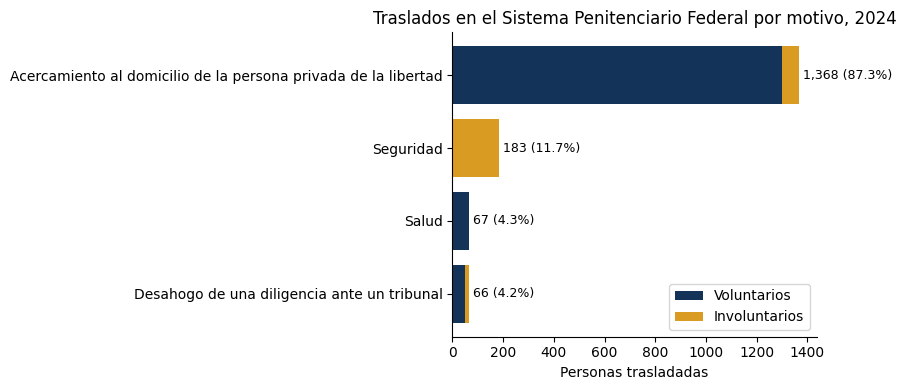

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.barh(df_plot['motivo'], df_plot['Voluntarios'], label='Voluntarios', color=PALETA[0])
ax.barh(df_plot['motivo'], df_plot['Involuntarios'], left=df_plot['Voluntarios'],
        label='Involuntarios', color=PALETA[2])

for i, (total, pct) in enumerate(zip(df_plot['Total'], df_plot['pct_del_total'])):
    ax.text(total + 15, i, f'{total:,} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Personas trasladadas')
ax.set_title('Traslados en el Sistema Penitenciario Federal por motivo, 2024')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('Traslados_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
catalogo_tipo = pd.read_csv(
    'Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/catalogos/traslado_b_cnsipef2025.csv',
    encoding='utf-8-sig'
)
catalogo_tipo

,traslado_b,descrip
0,1,Voluntarios
1,2,Involuntarios
2,3,No identificado
3,9,No especificado


In [23]:
df_incidentes = df_exploratorio3.merge(catalogo_tipo, on='traslado_b', how='left')
df_incidentes = df_incidentes.rename(columns={'descrip': 'tipo_traslado'})
df_incidentes

,traslado_b,rnsnni1,trainctt,trainc1,trainc2,trainc3,trainc4,trainc5,trainc6,tipo_traslado
0,1,1,27,0,0,1,5,0,21,Voluntarios
1,2,1,1,0,1,0,0,0,0,Involuntarios


In [24]:
df_incidentes = df_incidentes.drop(columns=['traslado_b'])

incidentes_cols = ['rnsnni1', 'trainctt', 'trainc1', 'trainc2', 'trainc3', 'trainc4', 'trainc5', 'trainc6']
nombres_incidentes = ['Hubo Incidentes', 'Total', 'Fugas', 'Muertes', 'Lesiones', 'Choques', 'Ataques', 'Otro']

mapa_columnas = dict(zip(incidentes_cols, nombres_incidentes))
df_incidentes = df_incidentes.rename(columns=mapa_columnas)

df_incidentes

,Hubo Incidentes,Total,Fugas,Muertes,Lesiones,Choques,Ataques,Otro,tipo_traslado
0,1,27,0,0,1,5,0,21,Voluntarios
1,1,1,0,1,0,0,0,0,Involuntarios


In [25]:
import matplotlib.colors as mcolors
import numpy as np

def paleta_extendida(n, colores=PALETA):
    cmap = mcolors.LinearSegmentedColormap.from_list('personalizada', colores)
    return [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, n)]

# Ejemplo: 10 centros federales
colores_10 = paleta_extendida(10)

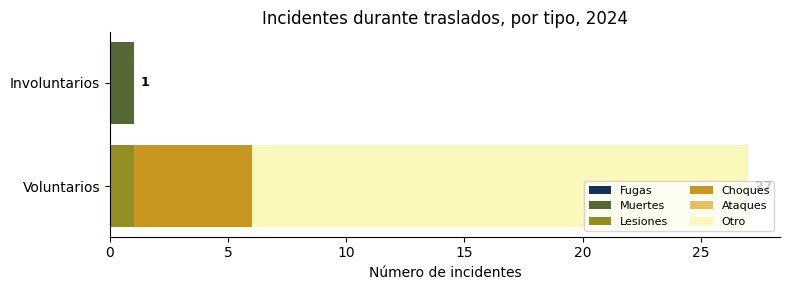

In [31]:
tipos_incidente = ['Fugas', 'Muertes', 'Lesiones', 'Choques', 'Ataques', 'Otro']
colores_incidentes = paleta_extendida(len(tipos_incidente))  # de la función que ya definimos

fig, ax = plt.subplots(figsize=(8, 3))

izquierda = pd.Series([0, 0], index=df_incidentes['tipo_traslado'])
for tipo, color in zip(tipos_incidente, colores_incidentes):
    valores = df_incidentes.set_index('tipo_traslado')[tipo]
    ax.barh(df_incidentes['tipo_traslado'], valores, left=izquierda, label=tipo, color=color)
    izquierda += valores

# Etiqueta de total al final de cada barra
for i, total in enumerate(df_incidentes['Total']):
    ax.text(total + 0.3, i, f'{total}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Número de incidentes')
ax.set_title('Incidentes durante traslados, por tipo, 2024')
ax.legend(loc='lower right', ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig('incidentes_traslados.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
catalogo_pais = pd.read_csv(
    'Censo Nacional de Sistema Penitenciario Federal (CNSIPEF) 2025/catalogos/capaises_c_cnsipef2025.csv',
    encoding='utf-8-sig'
)
catalogo_pais

,capaises_c,descrip
0,1,Alemania
1,2,Argentina
2,3,Australia
3,4,Bahamas
4,5,Belice
5,6,Bolivia
6,7,Brasil
7,8,Canadá
8,9,Chile
9,10,Colombia


In [28]:
df_extradiciones = df_exploratorio5.merge(catalogo_pais, on='capaises_c', how='left')
df_extradiciones

,capaises_c,totalca1,descrip
0,1,0.0,Alemania
1,2,0.0,Argentina
2,3,0.0,Australia
3,4,0.0,Bahamas
4,5,0.0,Belice
5,6,0.0,Bolivia
6,7,0.0,Brasil
7,8,0.0,Canadá
8,9,0.0,Chile
9,10,0.0,Colombia


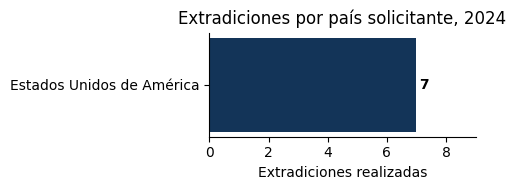

In [32]:
df_extradiciones_filtrado = df_extradiciones[df_extradiciones['totalca1'] > 0]

fig, ax = plt.subplots(figsize=(5, 2))
ax.barh(df_extradiciones_filtrado['descrip'], df_extradiciones_filtrado['totalca1'], color=PALETA[0])

ax.set_xlabel('Extradiciones realizadas')
ax.set_title('Extradiciones por país solicitante, 2024')
ax.set_xlim(0, df_extradiciones_filtrado['totalca1'].max() + 2)

for i, valor in enumerate(df_extradiciones_filtrado['totalca1']):
    ax.text(valor + 0.1, i, f'{int(valor)}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('extradiciones_traslados.png', dpi=150, bbox_inches='tight')
plt.show()